In [21]:
import tifffile
import imageio.v2
import matplotlib.pyplot as plt
from skimage import measure
import numpy as np
from skimage import (color, feature, filters, measure, morphology, segmentation, util)
from scipy import ndimage as ndi

In [2]:
Fluo_data = tifffile.imread('/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week2/Fluo_stack/CTL5439/Test2_Week_2_2022_09_08_11_02_00_Fluo5439_CS1A1S1_cropped_stack.tif')
Fluo_stack = Fluo_data.astype('float64')
Fluo_stack.shape

(840, 880, 880)

In [3]:
Fluo_max_activity = np.max(Fluo_stack,axis=0)

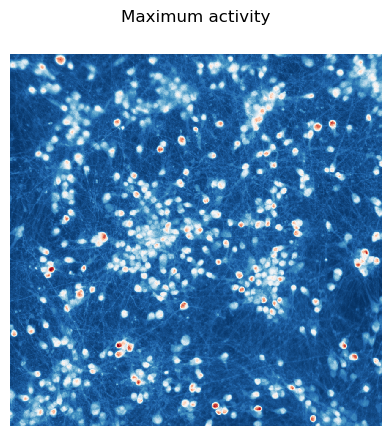

In [4]:
plt.matshow(Fluo_max_activity)

plt.set_cmap('RdBu_r')
#plt.colorbar()
plt.title('Maximum activity')

plt.axis('off')
plt.show()

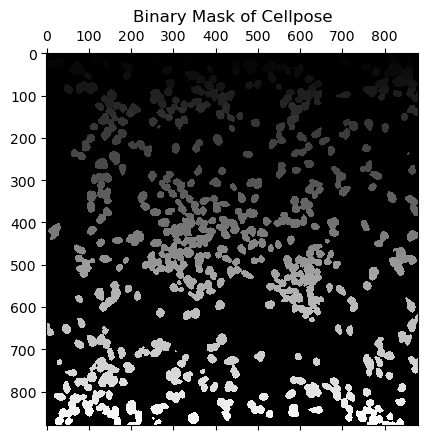

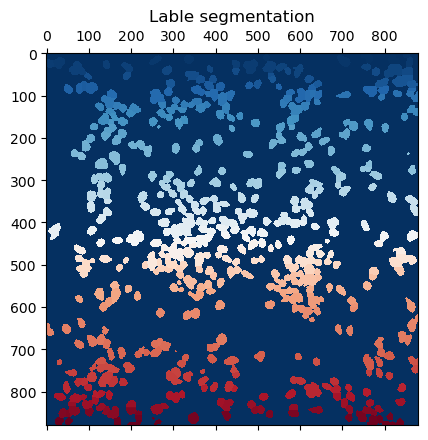

Total number of neurons that are segmented = 543


In [5]:
data_mask = imageio.v2.imread('/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week2/Cell_body_mask/Test2_Week_2_2022_09_08_11_02_00_Fluo5439_CS1A1S1_cropped_cell_body_mask.tif')
plt.matshow(data_mask ,cmap=plt.cm.gray)
plt.title('Binary Mask of Cellpose')

labeled_mask = measure.label(data_mask, background=None, return_num=False, connectivity=None)
plt.matshow(labeled_mask )
plt.title('Lable segmentation')
#plt.axis('off')
plt.show()


propsa = measure.regionprops(labeled_mask)
object_size=[]
for label in propsa:
    object_size.append(len(label.coords))
print('Total number of neurons that are segmented =',len(propsa))

In [7]:
# Calculate the average area of cell bodies
total_area = 0
for label in propsa:
    total_area += label.area

average_area = total_area / len(propsa)
print('Total number of neurons that are segmented =', len(propsa))
print('Average area of cell bodies =', average_area)


Total number of neurons that are segmented = 543
Average area of cell bodies = 342.2707182320442


185853.0

In [68]:
# Remove cell bodies larger than the average area
filtered_propsa = [label for label in propsa if label.area <= (1.5)*average_area and label.area >= (1/3) * average_area]
print('Number of cell bodies after removal =', len(filtered_propsa))

Number of cell bodies after removal = 469


In [69]:
len(filtered_propsa)/len(propsa)

0.8637200736648251

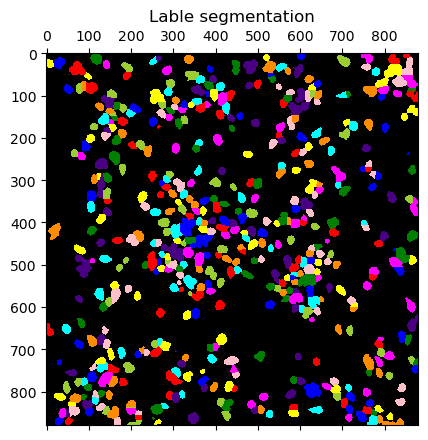

In [70]:
color_labels = color.label2rgb(data_mask,Fluo_max_activity, alpha=1, bg_label=0)
plt.matshow(color_labels)
plt.title('Lable segmentation')
#plt.axis('off')
plt.show()

In [71]:
# Create a new binary mask image with the same dimensions
filtered_mask = np.zeros_like(data_mask)

# Iterate through filtered regions and mark corresponding pixels as '1'
for label in filtered_propsa:
    for coord in label.coords:
        filtered_mask[coord[0], coord[1]] = 1

# # Display or save the new binary mask image
# plt.matshow(filtered_mask, cmap=plt.cm.gray)
# plt.title('Filtered Binary Mask of Cell Bodies')
# plt.show()

labeled_mask = measure.label(filtered_mask, background=None, return_num=False, connectivity=None)
# plt.matshow(labeled_mask )
# plt.title('Lable segmentation')
# #plt.axis('off')
# plt.show()

In [72]:
def wtr_shed(Cell):
    distance = ndi.distance_transform_edt(Cell) 
    local_max_coords = feature.peak_local_max(distance, min_distance=4) # change min_distance to separate more cells
    local_max_mask = np.zeros(distance.shape, dtype=bool)
    local_max_mask[tuple(local_max_coords.T)] = True
    markers = measure.label(local_max_mask)
    segmented_cells = segmentation.watershed(-distance, markers, mask=Cell)
    return segmented_cells

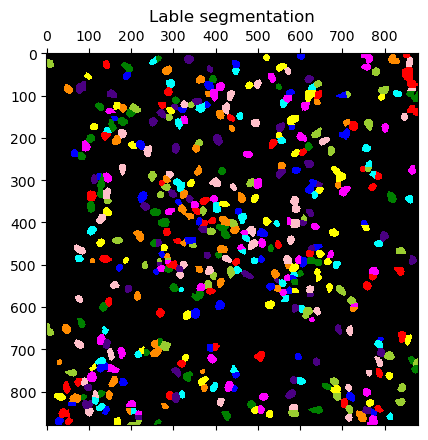

In [73]:
color_labels = color.label2rgb( wtr_shed(labeled_mask),Fluo_max_activity, alpha=1, bg_label=0)
plt.matshow(color_labels)
plt.title('Lable segmentation')
#plt.axis('off')
plt.show()